In [26]:
# !pip install underthesea

In [27]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from underthesea import word_tokenize
from wordcloud import WordCloud
from collections import Counter
import warnings

TEENCODE_DICT = {
    'ko': 'không', 'k': 'không', 'kh': 'không', 'bt': 'biết',
    'dc': 'được', 'đc': 'được', "ak":"à", "àh":"à",
    "uk":"ừ","uh":"ừ", "cmnl":"con mẹ nó luôn",
    'ad': 'admin', 'ntn': 'như thế nào',
    'v': 'vậy', 'r': 'rồi', "qtr":"quá trời",
    'cx': 'cũng',
    'ib': 'inbox',
    'rep': 'trả lời',
    'mn': 'mọi người',
    "goy":"rồi","xl":"xin lỗi",
    "j":"gì",
    "gòy":"rồi",
    'cmt': 'comment',
    'b': 'bạn',
    "tr":"trời",
    "hk":"không",
    "tt":"truyền thông",
    'e': 'em',
    'a': 'anh',
    "ng":"người", "lm":"làm", "cầu đặc": "đầu cặc", "kẹc":"cặc", "đ":"đéo", "gđ":"gia đình", "cằk":"cặc","cặk":"cặc", 'okela':'ok', "djt":"địt",
    "trây":"jack",  "bn":"bao nhiêu","bnh":"bao nhiêu", "cmm":"con mẹ","cm":"chúng mày","clm":"cái lồn má", 'vc':'vãi cả', 'cc':'cục cứt', 'loz':'lồn', 'l':'lồn', "lol":"lồn","lòn":"lồn", "lôn":"lồn",
    'vl':'vãi lồn',"vcl":"vãi cả lồn","vkl":"vãi cả lồn", "đcm":"địt con mẹ","đm":"địt mẹ","đcmm":"địt con mẹ","đcmmm":"địt con mẹ", "đb":"đầu buồi",
    'deo':'đéo','dell':'đéo', 'vcc':"vãi cả cứt", "occho":"óc chó", "t":"tôi", "chx":"chưa", "xg":"xong",
    "vcd":"vãi cả đái","vcđ":"vãi cả đái",
    "ae":"anh em", "j":"gì",
    "soll":"son","sol":"son",
    "vaiz":"vãi",
    "mn":"mọi người","mng":"mọi người",
    "bth":"bình thường",
    "m":"mày",
    "cm":"chúng mày",
    "mn":"mọi người",
    "st":"Sơn Tùng",
    "ch":"chưa",
    "vs":"với",
    "sv":"súc vật",
    "c":"cứt",
    "t.o.p":"top","to.p":"top",
    "ncc":"như cục cứt",
    "dit":"địt","djt":"địt",
    "hth":"hiếu thứ hai",
    "qc":"quảng cáo",
    "vn":"việt nam", "vaiz":"vãi",
    "r":"rồi", "nge":"nghe", "tiktok":"tik tok", "ytb":"youtube", "fb":"facebook", "vcut":"vãi cứt","shit":"cứt", "fl":"follow"
}

EMOJI_DICT = {
    "😢":" bieu_tuong_buon ",
    "🎉":" bieu_tuong_chuc_mung ",
    "❤":" bieu_tuong_trai_tim ",
    "🤣":" bieu_tuong_mat_cuoi ",
    "😂":" bieu_tuong_mat_cuoi ",
    "😭":" bieu_tuong_khoc ",
    "🔥":" bieu_tuong_chay ",
    "💩":" bieu_tuong_cut ",
    "🥰":" bieu_tuong_yeu_thuong ",
    "😮":" bieu_tuong_ngac_nhien ",
    "😅":" bieu_tuong_lo_lang ",
    "<3":" bieu_tuong_trai_tim "
}

STOP_WORDS = set()
with open('/content/drive/MyDrive/Dataset-Training-ML/vietnamese-stopwords-dash.txt', 'r', encoding='utf-8') as file:
    for line in file:
        word = line.strip()
        if word:
            STOP_WORDS.add(word)

warnings.filterwarnings('ignore')

# Hàm làm sạch cơ bản:
def preprocessing_basic(text):
  text = text.lower()
  text = re.sub(r'http\S+','',text)
  text = re.sub(r'<.*?>', '', text)
  text = text.strip()
  text = text.replace("t o p","top").replace("tốp","top")
  text = text.replace("v i e w","view").replace("c à y","cày")
  text = text.replace("đốn lòm","đóm lồn").replace("đốm lòn","đóm lồn")
  return text

def replace_teencode(text,teencode_dict):
  words = text.split()
  for idx,each_word in enumerate(words):
    if each_word in teencode_dict:
      words[idx] = teencode_dict[each_word]
  return ' '.join(words)

def replace_emoji(text,emoji_dict):
  for emoji, word in emoji_dict.items():
      text = text.replace(emoji, word)

  text = re.sub(r'\s+', ' ', text).strip()
  return text

def keep_chars(text):
  vietnamese_chars = 'àáạảãâầấậẩẫăằắặẳẵèéẹẻẽêềếệểễìíịỉĩòóọỏõôồốộổỗơờớợởỡùúụủũưừứựửữỳýỵỷỹđ'
  allowed_chars = vietnamese_chars + 'a-z_'
  unwanted_chars_pattern = re.compile(rf'[^{allowed_chars}\s]')
  text = unwanted_chars_pattern.sub(' ', text)
  text = re.sub(r'\s+',' ',text)
  text = text.strip()
  return text

def remove_duplicated_emoji(text):
    emoji_pattern = r'bieu_tuong_[a-zA-Z_]+'
    words = text.split()
    seen = set()
    complete_text = []
    for word in words:
        if re.fullmatch(emoji_pattern, word):
            if word not in seen:
                complete_text.append(word)
                seen.add(word)
        else:
            complete_text.append(word)
    return ' '.join(complete_text)

def preprocess_comment(text):
    global TEENCODE_DICT
    global EMOJI_DICT
    global STOP_WORDS
    text = preprocessing_basic(text)
    text = replace_teencode(text, TEENCODE_DICT)
    text = replace_emoji(text,EMOJI_DICT)
    text = keep_chars(text)
    text = remove_duplicated_emoji(text)
    return text

def get_top_words(comments_series, top_n=20, min_length=3):
    global STOP_WORDS
    all_words = []

    for comment in comments_series:
        words = word_tokenize(comment)
        filtered_words = [word for word in words
                        if (len(word) >= min_length and word not in STOP_WORDS) or (word == "hay")]
        all_words.extend(filtered_words)
    top_words = Counter(all_words)
    return top_words.most_common(top_n)

def get_top_2words(comments_series, top_n=20):
    all_words = []
    words_list = []
    for comment in comments_series:
        split_cmt = comment.split()
        words_list.append(split_cmt)

    for words in words_list:
        i = 0
        while(i < (len(words)-1)):
            all_words.append(words[i]+" "+words[i+1])
            i += 1
    top_words = Counter(all_words)
    return top_words.most_common(top_n)

def get_top_3words(comments_series, top_n=20):
    all_words = []
    words_list = []
    for comment in comments_series:
        split_cmt = comment.split()
        words_list.append(split_cmt)

    for words in words_list:
        i = 0
        while(i < (len(words)-2)):
            all_words.append(words[i]+" "+words[i+1]+" "+words[i+2])
            i += 1
    top_words = Counter(all_words)
    return top_words.most_common(top_n)

if __name__ == "__main__":

  comments_df = pd.read_csv('/content/drive/MyDrive/Dataset-Training-ML/Tram_dung_chan_Jack.csv', encoding='utf-8')

  print("Số lượng comment ban đầu: ", len(comments_df))
  comments_df.drop_duplicates(subset=['authorDisplayName',"textDisplay"], inplace=True)
  comments_df.dropna(subset=['textDisplay'], inplace=True)
  print("Số lượng comment sau khi lọc: ", len(comments_df))

  comments_only = comments_df["textDisplay"]

  comments_only = comments_only.apply(preprocess_comment)


Số lượng comment ban đầu:  51700
Số lượng comment sau khi lọc:  48343


In [28]:
a = get_top_words(comments_only)
b = get_top_2words(comments_only)
c = get_top_3words(comments_only)

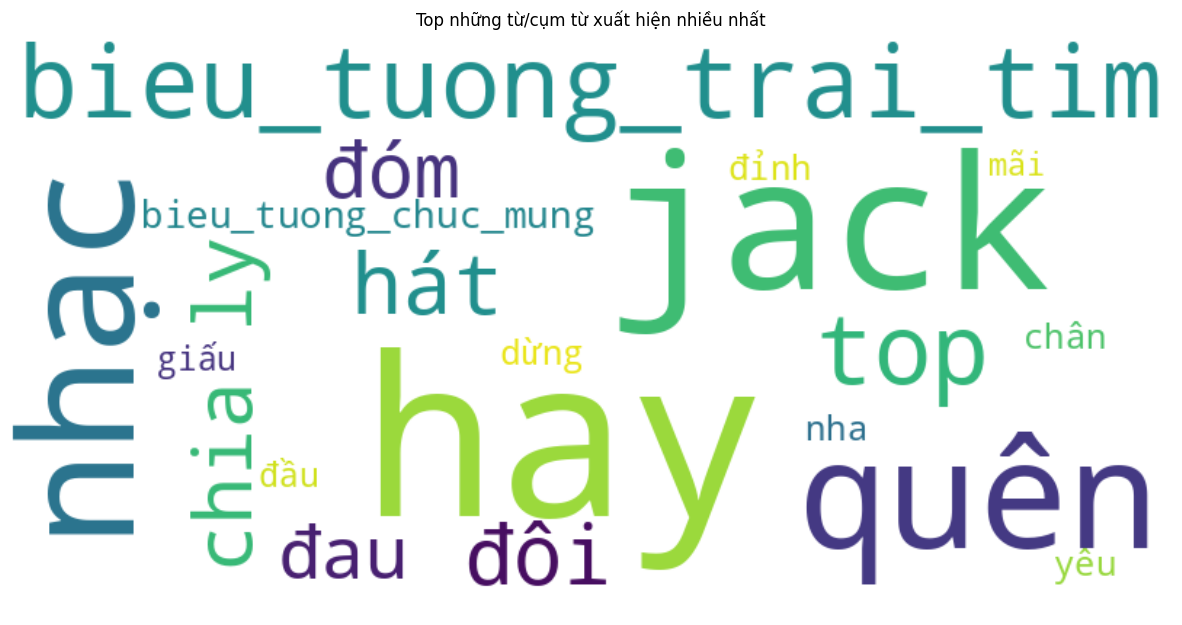

In [29]:
word_freq = dict(a)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Top những từ/cụm từ xuất hiện nhiều nhất")
plt.show()

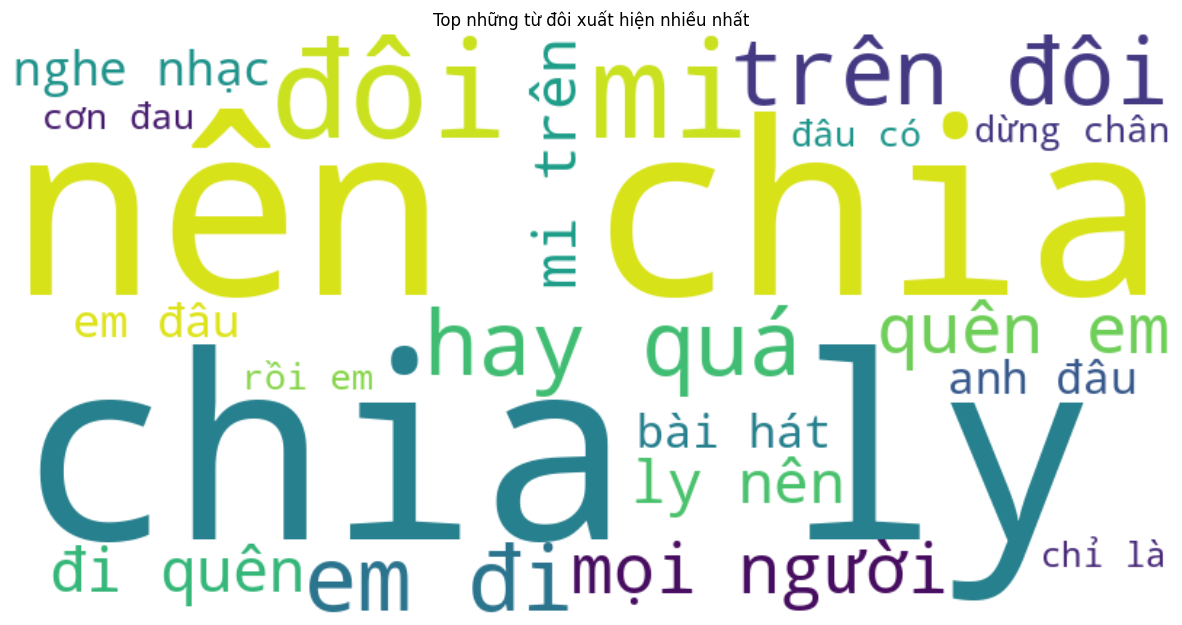

In [30]:
word_freq = dict(b)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Top những từ đôi xuất hiện nhiều nhất")
plt.show()

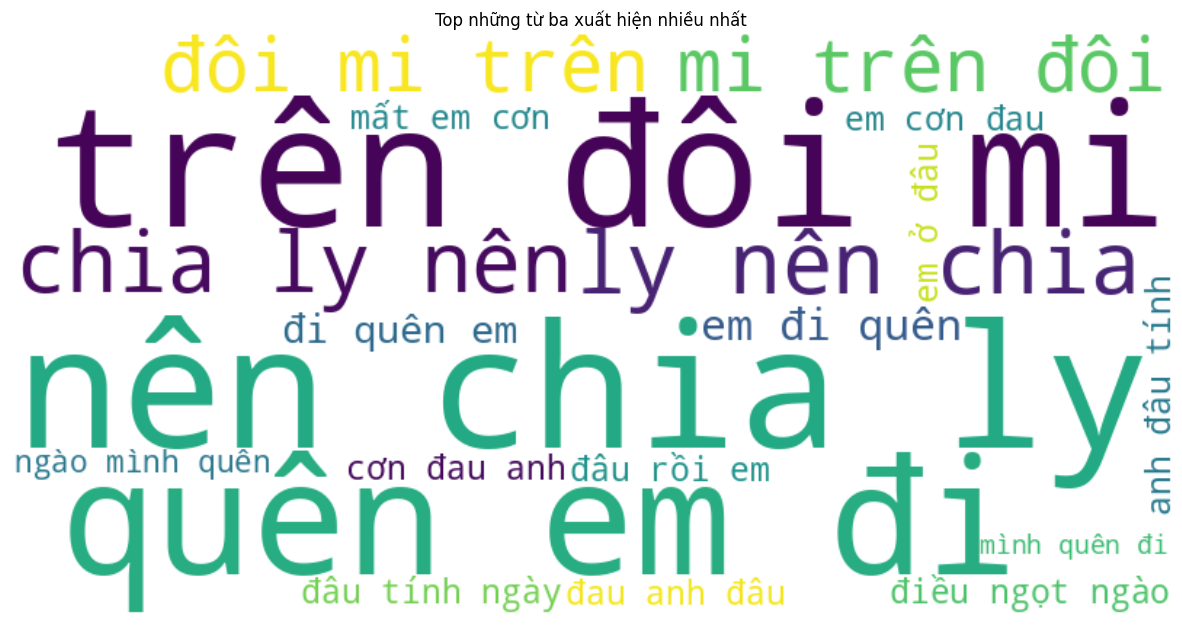

In [31]:
word_freq = dict(c)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Top những từ ba xuất hiện nhiều nhất")
plt.show()